# 📊 Ежедневный отчёт — iGaming
### OAS · CPA · Retention · Партнёры · GEO · Байеры · Связки
---
**Структура анализа:**
1. Сводка KPI — три когорты в одном месте
2. Тренд за 14 дней
3. Разбивка по партнёрам — кто дал подъём или спад
4. Разбивка по GEO
5. Разбивка по байерам и связкам
6. Прогноз OAS 3D / 7D для текущей когорты
7. Экспорт в Excel


- [результат расчётов](https://docs.google.com/spreadsheets/d/1GQipZ88F4Z-5K--rs5YF-XC5Ja3mkoKa/edit?usp=sharing&ouid=107564873355874201227&rtpof=true&sd=true)

## 0. Настройки и импорт

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter
from datetime import datetime, timedelta
import os
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────
#  НАСТРОЙКИ
# ─────────────────────────────────────────────
BASE_DATE        = '2026-02-14'   # сегодняшняя дата
DATA_FILE        = 'daily_data.csv'
EXCEL_OUT        = 'Daily_Report.xlsx'

OFFSET_1D        = 2   # дней назад для когорты 1D (данные уже финальные)
OFFSET_3D        = 4   # дней назад для когорты 3D
OFFSET_7D        = 8   # дней назад для когорты 7D

OAS_THRESHOLDS   = {'1D': 0.25, '3D': 0.30, '7D': 0.40}
FORECAST_LOOKBACK = 14  # дней истории для построения прогноза OAS
# ─────────────────────────────────────────────

plt.rcParams.update({
    'figure.facecolor': '#0F1117', 'axes.facecolor': '#1A1D2E',
    'axes.edgecolor':   '#2C3050', 'axes.labelcolor': '#C0C8D8',
    'xtick.color':      '#C0C8D8', 'ytick.color':     '#C0C8D8',
    'text.color':       '#FFFFFF', 'grid.color':       '#2C3050',
    'grid.alpha': 0.5, 'font.family': 'DejaVu Sans',
    'axes.titlesize': 12, 'axes.labelsize': 10, 'axes.titlepad': 10,
})

base     = pd.Timestamp(BASE_DATE)
date_1d  = base - timedelta(days=OFFSET_1D)
date_3d  = base - timedelta(days=OFFSET_3D)
date_7d  = base - timedelta(days=OFFSET_7D)

print('✓ Настройки загружены')
print(f'  Базовая дата  : {BASE_DATE}')
print(f'  Когорта 1D    : {date_1d.strftime("%d.%m.%Y")}')
print(f'  Когорта 3D    : {date_3d.strftime("%d.%m.%Y")}')
print(f'  Когорта 7D    : {date_7d.strftime("%d.%m.%Y")}')


✓ Настройки загружены
  Базовая дата  : 2026-02-14
  Когорта 1D    : 12.02.2026
  Когорта 3D    : 10.02.2026
  Когорта 7D    : 06.02.2026


## 1. Данные

Загружает `daily_data.csv`. Если файл не найден — генерируются синтетические данные для демонстрации.  
Замени блок загрузки на свой реальный файл.


In [34]:
def generate_synthetic_data(base_date, n_days=30):
    np.random.seed(42)
    partners = ['Aff_Alpha', 'Aff_Beta', 'Aff_Gamma', 'Aff_Delta', 'Aff_Epsilon']
    geos     = ['DE', 'AT', 'FI', 'NO', 'CA', 'NZ', 'PL']
    buyers   = ['Buyer_01', 'Buyer_02', 'Buyer_03', 'Buyer_04']

    rows = []
    start = base_date - timedelta(days=n_days + 10)

    for offset in range(n_days + 10):
        date = start + timedelta(days=offset)
        for partner in partners:
            for geo in np.random.choice(geos, size=2, replace=False):
                buyer  = np.random.choice(buyers)
                bundle = f'{partner}_{geo}_{buyer}'

                spend  = max(500, int(np.random.normal(4000, 1200)))
                ftd    = max(1, int(spend / np.random.normal(55, 15)))
                reg    = int(ftd * np.random.uniform(2.5, 4.5))

                avg_check = np.random.normal(90, 25)
                ret_1d    = np.random.uniform(0.20, 0.45)
                ret_3d    = ret_1d * np.random.uniform(1.3, 1.6)
                ret_7d    = ret_1d * np.random.uniform(1.6, 2.1)

                dc_1d  = int(ftd * ret_1d)
                ds_1d  = int(dc_1d * avg_check)
                dc_3d  = int(ftd * min(ret_3d, 0.9))
                ds_3d  = int(dc_3d * avg_check * np.random.uniform(0.9, 1.1))
                dc_7d  = int(ftd * min(ret_7d, 1.2))
                ds_7d  = int(dc_7d * avg_check * np.random.uniform(0.95, 1.15))
                du_1d  = dc_1d
                du_3d  = int(ftd * min(ret_3d * 0.8, 0.75))
                du_7d  = int(ftd * min(ret_7d * 0.7, 0.85))

                margin   = np.random.uniform(0.08, 0.15)
                cngr_1d  = int(ds_1d * (1 - margin))
                cngr_3d  = int(ds_3d * (1 - margin))
                cngr_7d  = int(ds_7d * (1 - margin))

                rows.append({
                    'Cohort Date':                         date,
                    'Partner':                             partner,
                    'GEO':                                 geo,
                    'Buyer':                               buyer,
                    'Bundle':                              bundle,
                    'Marketing Spend':                     spend,
                    'Registration C':                      reg,
                    'First Deposit C':                     ftd,
                    '1D Deposit C':                        dc_1d,
                    '1D Deposit S':                        ds_1d,
                    'Dep_Count_Unique_1D':                 du_1d,
                    '1D CNGR':                             cngr_1d,
                    '1D Deposit OAS':                      round(ds_1d / spend, 3),
                    '3D Deposit C':                        dc_3d,
                    '3D Deposit S':                        ds_3d,
                    'Dep_Count_Unique_3D':                 du_3d,
                    '3D CNGR':                             cngr_3d,
                    '3D Deposit OAS':                      round(ds_3d / spend, 3),
                    '7D Deposit C':                        dc_7d,
                    '7D Deposit S':                        ds_7d,
                    'Dep_Count_Unique_7D':                 du_7d,
                    '7D CNGR':                             cngr_7d,
                    '7D Deposit OAS':                      round(ds_7d / spend, 3),
                    'First Deposit 2 Deposit Conversion':  round(dc_1d / ftd * 100, 1),
                    'Crash FTD':                           round(np.random.uniform(2, 15), 1),
                })

    return pd.DataFrame(rows)


df = pd.read_csv(DATA_FILE, parse_dates=['Cohort Date'])
print(f'✓ Файл загружен: {DATA_FILE}')

df['Cohort Date'] = pd.to_datetime(df['Cohort Date'])
print(f'  Строк: {len(df):,}  |  Период: {df["Cohort Date"].min().date()} → {df["Cohort Date"].max().date()}')
print(f'  Партнёры  : {sorted(df["Partner"].unique())}')
print(f'  GEO       : {sorted(df["GEO"].unique())}')


⚠️  Файл не найден — генерируем синтетические данные
✓ Синтетические данные сохранены в daily_data.csv
  Строк: 400  |  Период: 2026-01-05 → 2026-02-13
  Партнёры  : ['Aff_Alpha', 'Aff_Beta', 'Aff_Delta', 'Aff_Epsilon', 'Aff_Gamma']
  GEO       : [np.str_('AT'), np.str_('CA'), np.str_('DE'), np.str_('FI'), np.str_('NO'), np.str_('NZ'), np.str_('PL')]


## 2. Вспомогательные функции

**`get_metrics(df, date, period)`** — агрегирует все строки за дату в одну строку метрик.  
Взвешенное среднее считается по FTD, чтобы крупные партнёры не занижали мелких.  
Возвращает: spend, ftd, dep_s, cngr, profit, OAS (dep_s / spend), CPA (spend / ftd),  
retention (уники / ftd × 100), avg_check, p50/p90, дельты OAS между периодами.

**`get_breakdown(df, date, dimension, period)`** — то же самое, но с группировкой  
по Partner / GEO / Buyer / Bundle. Показывает кто конкретно тянет OAS вниз или вверх.


In [35]:
def get_metrics(df, target_date, period='1D'):
    """Агрегирует все метрики для заданной даты и периода."""
    mask   = df['Cohort Date'].dt.date == pd.Timestamp(target_date).date()
    subset = df[mask].copy()
    if subset.empty:
        return None

    def s(col):
        return subset[col].sum() if col in subset.columns else 0

    def wmean(col):
        if col not in subset.columns:
            return 0
        total_ftd = subset['First Deposit C'].sum()
        if total_ftd == 0:
            return 0
        return (subset[col] * subset['First Deposit C']).sum() / total_ftd

    spend = s('Marketing Spend')
    ftd   = s('First Deposit C')
    reg   = s('Registration C')
    if spend == 0 or ftd == 0:
        return None

    if period == '1D':
        dep_c    = s('1D Deposit C')
        dep_s    = s('1D Deposit S')
        dep_uniq = s('Dep_Count_Unique_1D')
        cngr     = s('1D CNGR')
    elif period == '3D':
        dep_c    = s('3D Deposit C')
        dep_s    = s('3D Deposit S')
        dep_uniq = s('Dep_Count_Unique_3D')
        cngr     = s('3D CNGR')
    else:
        dep_c    = s('7D Deposit C')
        dep_s    = s('7D Deposit S')
        dep_uniq = s('Dep_Count_Unique_7D')
        cngr     = s('7D CNGR')

    oas_1d = round(s('1D Deposit S') / spend, 3)
    oas_3d = round(s('3D Deposit S') / spend, 3)
    oas_7d = round(s('7D Deposit S') / spend, 3)
    oas    = round(dep_s / spend, 3)
    cpa    = round(spend / ftd, 1)
    ret    = round(dep_uniq / ftd * 100, 1) if ftd > 0 else 0
    avg_ch = round(dep_s / dep_c, 1) if dep_c > 0 else 0
    fd2dep = round(wmean('First Deposit 2 Deposit Conversion'), 1)
    crash  = round(subset['Crash FTD'].mean(), 1) if 'Crash FTD' in subset.columns else 0

    return {
        'spend': int(spend), 'ftd': int(ftd), 'reg': int(reg),
        'dep_c': int(dep_c), 'dep_s': int(dep_s), 'dep_uniq': int(dep_uniq),
        'cngr': int(cngr), 'profit': int(cngr - spend),
        'avg_ch': avg_ch, 'p50': round(avg_ch * 0.6, 1), 'p90': round(avg_ch * 2.0, 1),
        'oas': oas, 'cpa': cpa, 'ret': ret, 'fd2dep': fd2dep, 'crash': crash,
        'oas_1d': oas_1d, 'oas_3d': oas_3d, 'oas_7d': oas_7d,
        'delta_1d_3d': round(oas_3d - oas_1d, 3),
        'delta_3d_7d': round(oas_7d - oas_3d, 3),
        'delta_total': round(oas_7d - oas_1d, 3),
        'period': period,
    }


def get_breakdown(df, target_date, dimension, period='1D'):
    """Метрики в разбивке по партнёру / GEO / байеру / связке."""
    mask   = df['Cohort Date'].dt.date == pd.Timestamp(target_date).date()
    subset = df[mask].copy()
    if subset.empty:
        return pd.DataFrame()

    grp = subset.groupby(dimension).agg(
        spend    = ('Marketing Spend', 'sum'),
        ftd      = ('First Deposit C', 'sum'),
        dep_s    = (f'{period} Deposit S', 'sum'),
        dep_c    = (f'{period} Deposit C', 'sum'),
        dep_uniq = (f'Dep_Count_Unique_{period}', 'sum'),
        cngr     = (f'{period} CNGR', 'sum'),
    ).reset_index()

    grp['oas']    = (grp['dep_s'] / grp['spend']).round(3)
    grp['cpa']    = (grp['spend'] / grp['ftd']).round(1)
    grp['ret']    = (grp['dep_uniq'] / grp['ftd'] * 100).round(1)
    grp['profit'] = grp['cngr'] - grp['spend']
    grp['avg_ch'] = (grp['dep_s'] / grp['dep_c'].replace(0, np.nan)).round(1).fillna(0)
    return grp.sort_values('spend', ascending=False)


def oas_flag(val, period):
    return '🟢' if val >= OAS_THRESHOLDS.get(period, 0) else '🔴'


print('✓ Функции готовы')


✓ Функции готовы


## 3. Сводка KPI — три когорты в одном месте

Одновременно смотрим три горизонта:
- **1D** — когорта позавчера: данные по первому дню уже полные
- **3D** — когорта 4 дня назад: видим рост OAS за три дня
- **7D** — когорта 8 дней назад: финальный срез недельного окна

Для 3D и 7D дополнительно показывается траектория OAS: 1D → 3D → 7D с дельтой.


In [36]:
m1d = get_metrics(df, date_1d, '1D')
m3d = get_metrics(df, date_3d, '3D')
m7d = get_metrics(df, date_7d, '7D')

def print_block(date, m, label):
    if m is None:
        print(f'  ⚠️  {label}: нет данных')
        return
    flag  = oas_flag(m['oas'], m['period'])
    thr   = OAS_THRESHOLDS[m['period']]
    print(f'  ┌─ {label} — когорта {pd.Timestamp(date).strftime("%d.%m")} ───────────────────────────')
    print(f'  │  Spend: €{m["spend"]:,}  |  FTD: {m["ftd"]}  |  CPA: €{m["cpa"]:.1f}  |  Рег: {m["reg"]}')
    print(f'  │  Dep Summ: €{m["dep_s"]:,}  |  CNGR: €{m["cngr"]:,}  |  Profit: €{m["profit"]:,}')
    print(f'  │  OAS: {m["oas"]:.3f} {flag} (порог {thr})  |  Retention: {m["ret"]:.1f}%  |  FD→2Dep: {m["fd2dep"]:.1f}%')
    print(f'  │  Avg check: €{m["avg_ch"]:.1f}  |  P50: €{m["p50"]:.1f}  |  P90: €{m["p90"]:.1f}')
    if m['period'] == '3D':
        print(f'  │  OAS 1D → 3D: {m["oas_1d"]:.3f} → {m["oas_3d"]:.3f}  (Δ {m["delta_1d_3d"]:+.3f})')
    elif m['period'] == '7D':
        print(f'  │  OAS 1D → 3D → 7D: {m["oas_1d"]:.3f} → {m["oas_3d"]:.3f} → {m["oas_7d"]:.3f}  (Δ итого {m["delta_total"]:+.3f})')
    print(f'  └──────────────────────────────────────────────────────────────────')

print('\n📊 СВОДКА KPI ПО КОГОРТАМ')
print('=' * 70)
print_block(date_1d, m1d, '1D')
print()
print_block(date_3d, m3d, '3D')
print()
print_block(date_7d, m7d, '7D')



📊 СВОДКА KPI ПО КОГОРТАМ
  ┌─ 1D — когорта 12.02 ───────────────────────────
  │  Spend: €37,996  |  FTD: 698  |  CPA: €54.4  |  Рег: 2608
  │  Dep Summ: €16,803  |  CNGR: €14,777  |  Profit: €-23,219
  │  OAS: 0.442 🟢 (порог 0.25)  |  Retention: 33.7%  |  FD→2Dep: 33.7%
  │  Avg check: €71.5  |  P50: €42.9  |  P90: €143.0
  └──────────────────────────────────────────────────────────────────

  ┌─ 3D — когорта 10.02 ───────────────────────────
  │  Spend: €38,845  |  FTD: 697  |  CPA: €55.7  |  Рег: 2380
  │  Dep Summ: €27,235  |  CNGR: €23,942  |  Profit: €-14,903
  │  OAS: 0.701 🟢 (порог 0.3)  |  Retention: 36.4%  |  FD→2Dep: 31.4%
  │  Avg check: €85.4  |  P50: €51.2  |  P90: €170.8
  │  OAS 1D → 3D: 0.483 → 0.701  (Δ +0.218)
  └──────────────────────────────────────────────────────────────────

  ┌─ 7D — когорта 06.02 ───────────────────────────
  │  Spend: €34,119  |  FTD: 669  |  CPA: €51.0  |  Рег: 2326
  │  Dep Summ: €42,783  |  CNGR: €37,838  |  Profit: €3,719
  │  OAS: 1.254

## 4. Тренд за 14 дней

Динамика 1D-метрик за последние две недели.  
Зелёные столбцы OAS — выше порога, красные — ниже.  
Пунктирная линия на каждом графике — среднее за период.


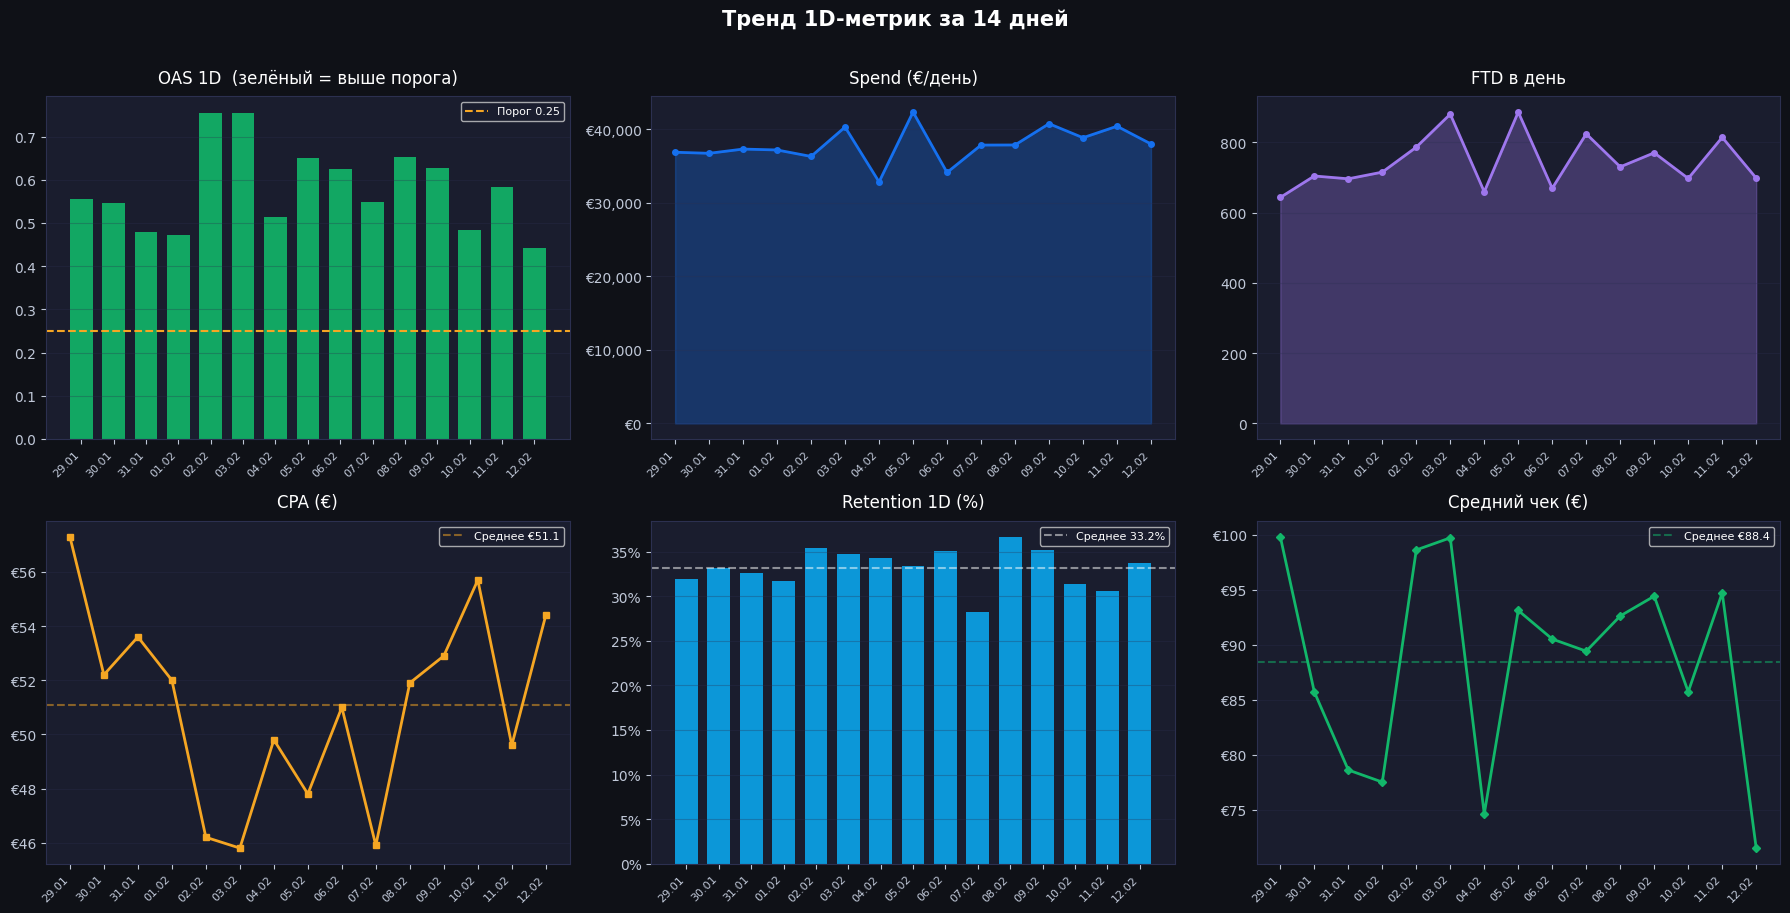

In [37]:
history = []
for offset in range(1, 16):
    d = base - timedelta(days=offset + 1)
    m = get_metrics(df, d, '1D')
    if m:
        m['date'] = d
        history.append(m)

hist_df = pd.DataFrame(history).sort_values('date')
hist_df['label'] = hist_df['date'].dt.strftime('%d.%m')

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
fig.suptitle('Тренд 1D-метрик за 14 дней', fontsize=15, fontweight='bold', color='white', y=1.01)

thr_1d = OAS_THRESHOLDS['1D']
x      = range(len(hist_df))
labels = hist_df['label'].tolist()

# OAS 1D
colors_oas = ['#F04438' if v < thr_1d else '#12B76A' for v in hist_df['oas']]
axes[0,0].bar(x, hist_df['oas'], color=colors_oas, edgecolor='none', width=0.7, alpha=0.9)
axes[0,0].axhline(thr_1d, color='#F5A623', linestyle='--', linewidth=1.5, label=f'Порог {thr_1d}')
axes[0,0].set_title('OAS 1D  (зелёный = выше порога)')
axes[0,0].set_xticks(x); axes[0,0].set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
axes[0,0].legend(fontsize=8)

# Spend
axes[0,1].fill_between(x, hist_df['spend'], alpha=0.3, color='#1570EF')
axes[0,1].plot(x, hist_df['spend'], color='#1570EF', linewidth=2, marker='o', markersize=4)
axes[0,1].set_title('Spend (€/день)')
axes[0,1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'€{v:,.0f}'))
axes[0,1].set_xticks(x); axes[0,1].set_xticklabels(labels, rotation=45, ha='right', fontsize=8)

# FTD
axes[0,2].fill_between(x, hist_df['ftd'], alpha=0.3, color='#9E77ED')
axes[0,2].plot(x, hist_df['ftd'], color='#9E77ED', linewidth=2, marker='o', markersize=4)
axes[0,2].set_title('FTD в день')
axes[0,2].set_xticks(x); axes[0,2].set_xticklabels(labels, rotation=45, ha='right', fontsize=8)

# CPA
axes[1,0].plot(x, hist_df['cpa'], color='#F5A623', linewidth=2, marker='s', markersize=4)
axes[1,0].axhline(hist_df['cpa'].mean(), linestyle='--', color='#F5A623', alpha=0.5,
                   label=f'Среднее €{hist_df["cpa"].mean():.1f}')
axes[1,0].set_title('CPA (€)')
axes[1,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'€{v:.0f}'))
axes[1,0].set_xticks(x); axes[1,0].set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
axes[1,0].legend(fontsize=8)

# Retention
axes[1,1].bar(x, hist_df['ret'], color='#0BA5EC', edgecolor='none', width=0.7, alpha=0.9)
axes[1,1].axhline(hist_df['ret'].mean(), linestyle='--', color='white', alpha=0.5,
                   label=f'Среднее {hist_df["ret"].mean():.1f}%')
axes[1,1].set_title('Retention 1D (%)')
axes[1,1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}%'))
axes[1,1].set_xticks(x); axes[1,1].set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
axes[1,1].legend(fontsize=8)

# Avg Check
axes[1,2].plot(x, hist_df['avg_ch'], color='#12B76A', linewidth=2, marker='D', markersize=4)
axes[1,2].axhline(hist_df['avg_ch'].mean(), linestyle='--', color='#12B76A', alpha=0.5,
                   label=f'Среднее €{hist_df["avg_ch"].mean():.1f}')
axes[1,2].set_title('Средний чек (€)')
axes[1,2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'€{v:.0f}'))
axes[1,2].set_xticks(x); axes[1,2].set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
axes[1,2].legend(fontsize=8)

for ax in axes.flat:
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


## 5. Разбивка по партнёрам — кто дал подъём / спад

Анализируем когорту **1D** (позавчера) — данные по первому дню уже финальные.  
Смотрим OAS, CPA, Retention и Profit по каждому партнёру.  
🔴 — OAS ниже порога, нужен разбор причин или пауза трафика.



📋 ПАРТНЁРЫ | Когорта 12.02 | 1D  (порог 0.25)
---------------------------------------------------------------------------
  Партнёр               Spend    FTD     CPA    Dep S     OAS   Ret%    Profit
---------------------------------------------------------------------------
  Aff_Epsilon           8,419    144    58.5    3,034   0.360  29.9%   -5,732  🟢
  Aff_Alpha             8,195    155    52.9    3,441   0.420  34.8%   -5,149  🟢
  Aff_Delta             8,125    116    70.0    2,518   0.310  34.5%   -5,869  🟢
  Aff_Gamma             7,095    160    44.3    4,866   0.686  34.4%   -2,892  🟢
  Aff_Beta              6,162    123    50.1    2,944   0.478  35.0%   -3,577  🟢


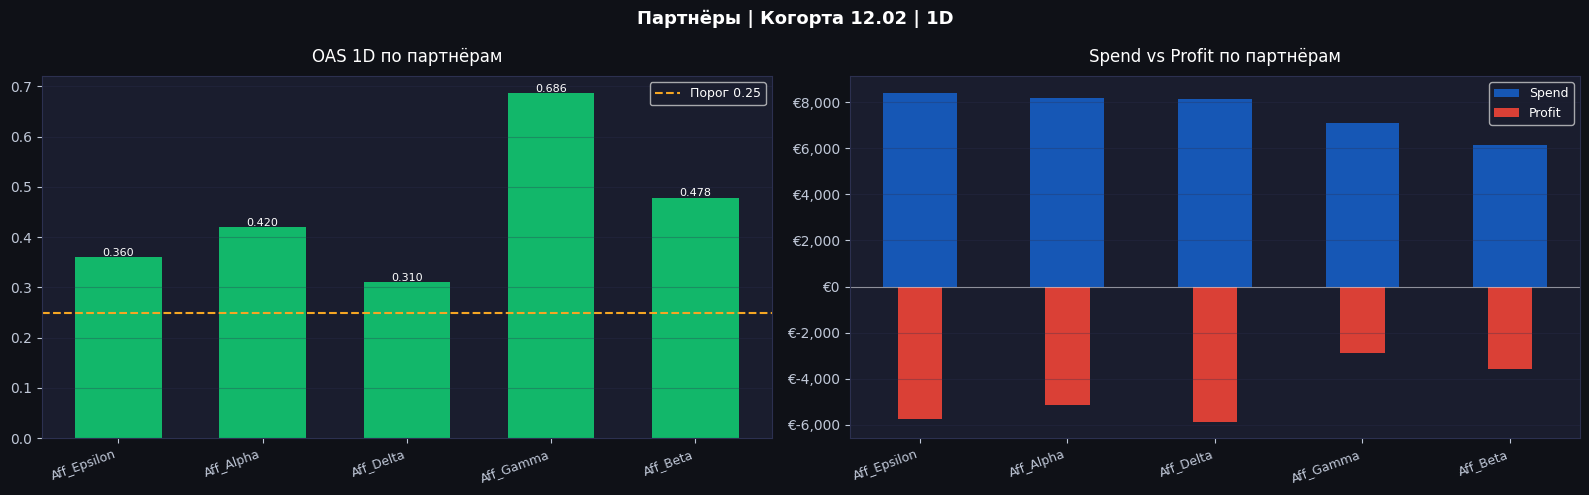

In [38]:
partners_1d = get_breakdown(df, date_1d, 'Partner', '1D')

print(f'\n📋 ПАРТНЁРЫ | Когорта {date_1d.strftime("%d.%m")} | 1D  (порог {OAS_THRESHOLDS["1D"]})')
print('-' * 75)
print(f'  {"Партнёр":<18} {"Spend":>8} {"FTD":>6} {"CPA":>7} {"Dep S":>8} {"OAS":>7} {"Ret%":>6} {"Profit":>9}')
print('-' * 75)
for _, row in partners_1d.iterrows():
    flag = oas_flag(row['oas'], '1D')
    sign = '+' if row['profit'] >= 0 else ''
    print(f'  {str(row["Partner"]):<18} {int(row["spend"]):>8,} {int(row["ftd"]):>6} '
          f'{row["cpa"]:>7.1f} {int(row["dep_s"]):>8,} {row["oas"]:>7.3f} '
          f'{row["ret"]:>5.1f}% {sign}{int(row["profit"]):>8,}  {flag}')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(f'Партнёры | Когорта {date_1d.strftime("%d.%m")} | 1D', fontsize=13, fontweight='bold', color='white')

names  = partners_1d['Partner'].tolist()
xp     = range(len(names))
colors = ['#F04438' if v < OAS_THRESHOLDS['1D'] else '#12B76A' for v in partners_1d['oas']]

axes[0].bar(xp, partners_1d['oas'], color=colors, edgecolor='none', width=0.6)
axes[0].axhline(OAS_THRESHOLDS['1D'], color='#F5A623', linestyle='--', linewidth=1.5,
                label=f'Порог {OAS_THRESHOLDS["1D"]}')
axes[0].set_title('OAS 1D по партнёрам')
axes[0].set_xticks(xp); axes[0].set_xticklabels(names, rotation=20, ha='right', fontsize=9)
for i, v in enumerate(partners_1d['oas']):
    axes[0].text(i, v + 0.003, f'{v:.3f}', ha='center', fontsize=8, color='white')
axes[0].legend(fontsize=9)

colors_pr = ['#12B76A' if v >= 0 else '#F04438' for v in partners_1d['profit']]
axes[1].bar(xp, partners_1d['spend'], label='Spend', color='#1570EF', alpha=0.7, edgecolor='none', width=0.5)
axes[1].bar(xp, partners_1d['profit'], label='Profit', color=colors_pr, alpha=0.9, edgecolor='none', width=0.3)
axes[1].axhline(0, color='white', linewidth=0.8, alpha=0.5)
axes[1].set_title('Spend vs Profit по партнёрам')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'€{v:,.0f}'))
axes[1].set_xticks(xp); axes[1].set_xticklabels(names, rotation=20, ha='right', fontsize=9)
axes[1].legend(fontsize=9)

for ax in axes:
    ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## 6. Разбивка по GEO

Три среза: OAS по странам, объём спенда и CPA.  
Помогает увидеть какое гео даёт дорогой или дешёвый трафик  
и где маржинальность падает ниже порога.



🌍 GEO | Когорта 12.02 | 1D
-----------------------------------------------------------------
  GEO         Spend    FTD     CPA     OAS   Ret%    Profit
-----------------------------------------------------------------
  NZ          9,517    179    53.2   0.384  27.4%   -6,351  🟢
  AT          7,614    136    56.0   0.500  36.0%   -4,268  🟢
  NO          7,546    160    47.2   0.521  35.6%   -4,064  🟢
  PL          5,451    104    52.4   0.551  35.6%   -2,832  🟢
  FI          4,506     57    79.1   0.162  33.3%   -3,838  🔴
  DE          3,362     62    54.2   0.503  38.7%   -1,866  🟢


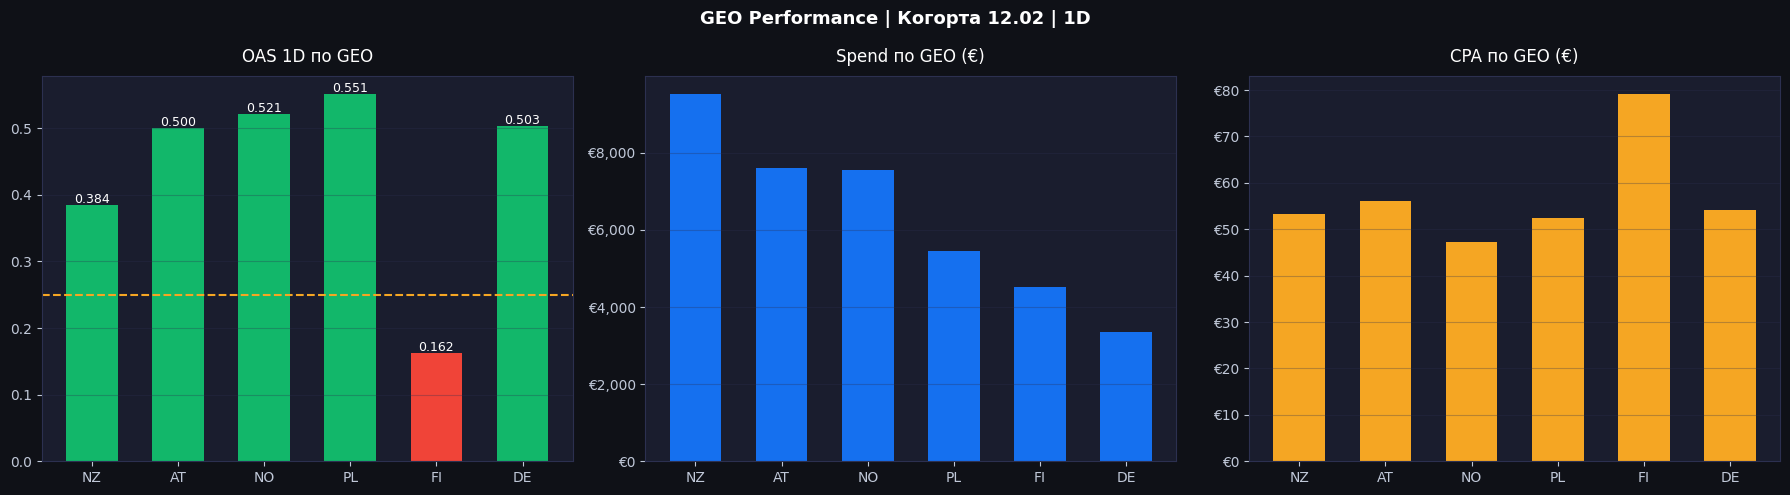

In [39]:
geo_1d = get_breakdown(df, date_1d, 'GEO', '1D')

print(f'\n🌍 GEO | Когорта {date_1d.strftime("%d.%m")} | 1D')
print('-' * 65)
print(f'  {"GEO":<8} {"Spend":>8} {"FTD":>6} {"CPA":>7} {"OAS":>7} {"Ret%":>6} {"Profit":>9}')
print('-' * 65)
for _, row in geo_1d.iterrows():
    flag = oas_flag(row['oas'], '1D')
    sign = '+' if row['profit'] >= 0 else ''
    print(f'  {str(row["GEO"]):<8} {int(row["spend"]):>8,} {int(row["ftd"]):>6} '
          f'{row["cpa"]:>7.1f} {row["oas"]:>7.3f} {row["ret"]:>5.1f}% '
          f'{sign}{int(row["profit"]):>8,}  {flag}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'GEO Performance | Когорта {date_1d.strftime("%d.%m")} | 1D', fontsize=13, fontweight='bold', color='white')

gnames   = geo_1d['GEO'].tolist()
xg       = range(len(gnames))
colors_g = ['#F04438' if v < OAS_THRESHOLDS['1D'] else '#12B76A' for v in geo_1d['oas']]

axes[0].bar(xg, geo_1d['oas'], color=colors_g, edgecolor='none', width=0.6)
axes[0].axhline(OAS_THRESHOLDS['1D'], color='#F5A623', linestyle='--', linewidth=1.5)
axes[0].set_title('OAS 1D по GEO')
axes[0].set_xticks(xg); axes[0].set_xticklabels(gnames, fontsize=10)
for i, v in enumerate(geo_1d['oas']):
    axes[0].text(i, v + 0.003, f'{v:.3f}', ha='center', fontsize=9, color='white')

axes[1].bar(xg, geo_1d['spend'], color='#1570EF', edgecolor='none', width=0.6)
axes[1].set_title('Spend по GEO (€)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'€{v:,.0f}'))
axes[1].set_xticks(xg); axes[1].set_xticklabels(gnames, fontsize=10)

axes[2].bar(xg, geo_1d['cpa'], color='#F5A623', edgecolor='none', width=0.6)
axes[2].set_title('CPA по GEO (€)')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'€{v:.0f}'))
axes[2].set_xticks(xg); axes[2].set_xticklabels(gnames, fontsize=10)

for ax in axes:
    ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## 7. Байеры и связки — детализация

Разбивка по байерам: кто из команды работает в плюс, кто в минус.  
Топ-10 связок по спенду — самые крупные позиции с OAS-флагами.  
Связка = Partner + GEO + Buyer в одной строке.



👤 БАЙЕРЫ | Когорта 12.02 | 1D
-----------------------------------------------------------------
  Байер             Spend    FTD     CPA     OAS   Ret%    Profit
-----------------------------------------------------------------
  Buyer_01         13,319    223    59.7   0.407  35.9%   -8,536  🟢
  Buyer_03         12,671    218    58.1   0.406  31.2%   -8,134  🟢
  Buyer_04          7,095    160    44.3   0.686  34.4%   -2,892  🟢
  Buyer_02          4,911     97    50.6   0.279  33.0%   -3,657  🟢

🔗 ТОП-10 СВЯЗОК | Когорта 12.02 | 1D  (по Spend)
--------------------------------------------------------------------------------
  Связка                                 Spend   FTD     OAS    Profit
--------------------------------------------------------------------------------
  Aff_Epsilon_NZ_Buyer_03                5,057    82   0.266   -3,866  🟢
  Aff_Alpha_NO_Buyer_02                  4,911    97   0.279   -3,657  🟢
  Aff_Delta_FI_Buyer_01                  4,506    57   0.162   -3,838 

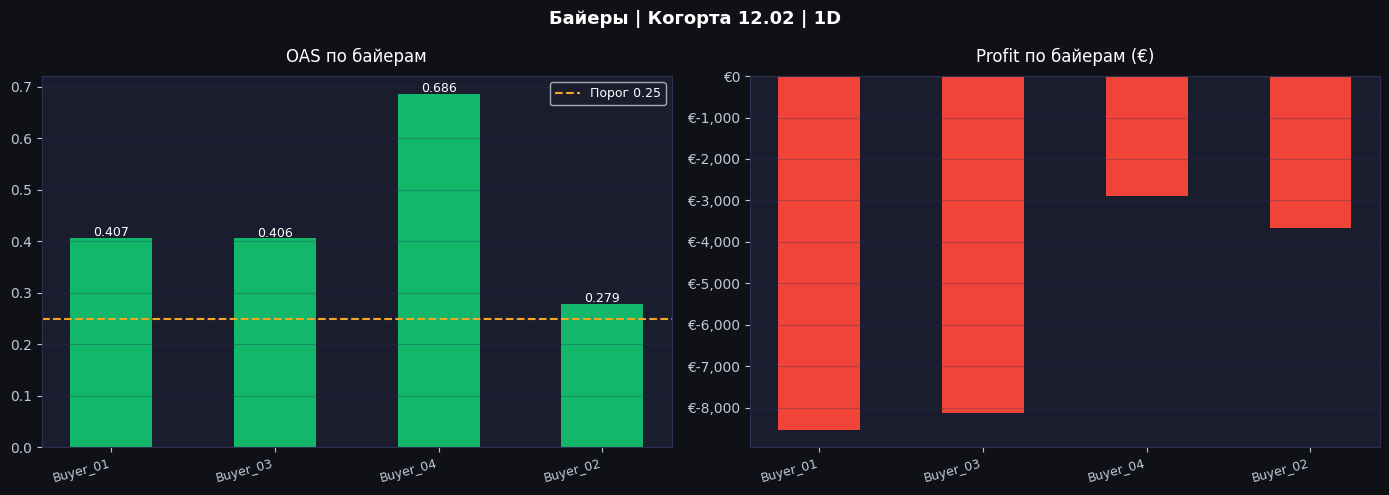

In [40]:
buyers_1d  = get_breakdown(df, date_1d, 'Buyer',  '1D')
bundles_1d = get_breakdown(df, date_1d, 'Bundle', '1D')

print(f'\n👤 БАЙЕРЫ | Когорта {date_1d.strftime("%d.%m")} | 1D')
print('-' * 65)
print(f'  {"Байер":<14} {"Spend":>8} {"FTD":>6} {"CPA":>7} {"OAS":>7} {"Ret%":>6} {"Profit":>9}')
print('-' * 65)
for _, row in buyers_1d.iterrows():
    flag = oas_flag(row['oas'], '1D')
    sign = '+' if row['profit'] >= 0 else ''
    print(f'  {str(row["Buyer"]):<14} {int(row["spend"]):>8,} {int(row["ftd"]):>6} '
          f'{row["cpa"]:>7.1f} {row["oas"]:>7.3f} {row["ret"]:>5.1f}% '
          f'{sign}{int(row["profit"]):>8,}  {flag}')

print(f'\n🔗 ТОП-10 СВЯЗОК | Когорта {date_1d.strftime("%d.%m")} | 1D  (по Spend)')
print('-' * 80)
print(f'  {"Связка":<35} {"Spend":>8} {"FTD":>5} {"OAS":>7} {"Profit":>9}')
print('-' * 80)
for _, row in bundles_1d.head(10).iterrows():
    flag = oas_flag(row['oas'], '1D')
    sign = '+' if row['profit'] >= 0 else ''
    print(f'  {str(row["Bundle"]):<35} {int(row["spend"]):>8,} {int(row["ftd"]):>5} '
          f'{row["oas"]:>7.3f} {sign}{int(row["profit"]):>8,}  {flag}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Байеры | Когорта {date_1d.strftime("%d.%m")} | 1D', fontsize=13, fontweight='bold', color='white')

bnames   = buyers_1d['Buyer'].tolist()
xb       = range(len(bnames))
colors_b = ['#F04438' if v < OAS_THRESHOLDS['1D'] else '#12B76A' for v in buyers_1d['oas']]

axes[0].bar(xb, buyers_1d['oas'], color=colors_b, edgecolor='none', width=0.5)
axes[0].axhline(OAS_THRESHOLDS['1D'], color='#F5A623', linestyle='--', linewidth=1.5,
                label=f'Порог {OAS_THRESHOLDS["1D"]}')
axes[0].set_title('OAS по байерам')
axes[0].set_xticks(xb); axes[0].set_xticklabels(bnames, rotation=15, ha='right', fontsize=9)
for i, v in enumerate(buyers_1d['oas']):
    axes[0].text(i, v + 0.003, f'{v:.3f}', ha='center', fontsize=9, color='white')
axes[0].legend(fontsize=9)

colors_pr = ['#12B76A' if v >= 0 else '#F04438' for v in buyers_1d['profit']]
axes[1].bar(xb, buyers_1d['profit'], color=colors_pr, edgecolor='none', width=0.5)
axes[1].axhline(0, color='white', linewidth=0.8, alpha=0.5)
axes[1].set_title('Profit по байерам (€)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'€{v:,.0f}'))
axes[1].set_xticks(xb); axes[1].set_xticklabels(bnames, rotation=15, ha='right', fontsize=9)

for ax in axes:
    ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## 8. Траектория OAS: 1D → 3D → 7D

Для каждой исторической когорты (у которой уже есть все три периода)  
строим кривую роста OAS. Пунктирные линии — пороги для каждого периода.  
Закрашенная область между 1D и 7D показывает зону роста.  
Позволяет понять: нынешняя когорта растёт быстрее или медленнее исторической нормы?


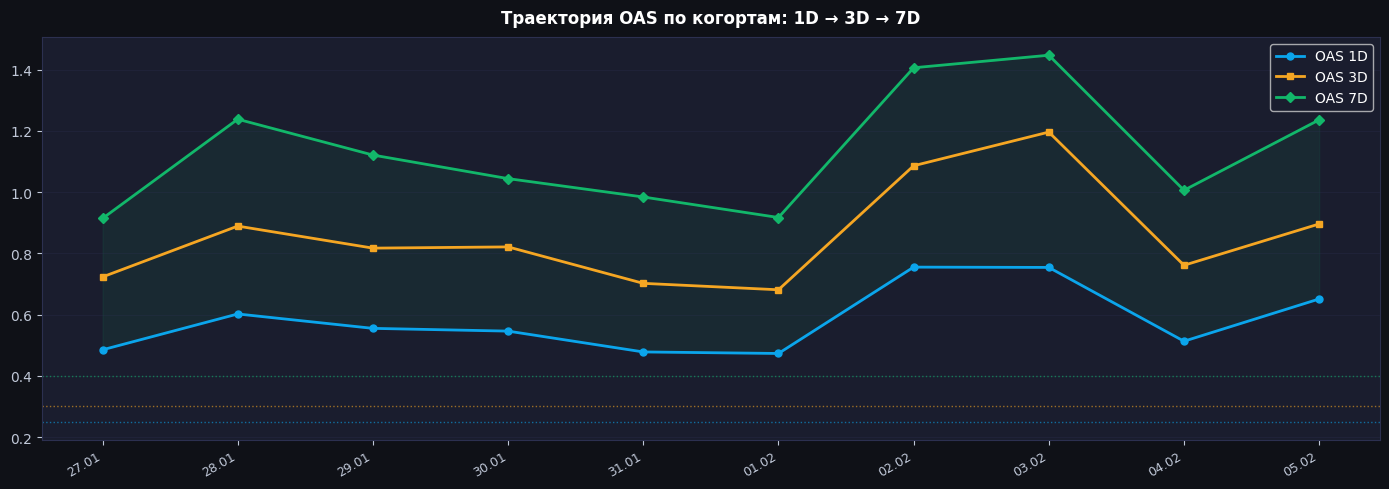

In [41]:
trajectories = []
for offset in range(8, 22):
    d  = base - timedelta(days=offset + 1)
    m1 = get_metrics(df, d, '1D')
    m3 = get_metrics(df, d, '3D')
    m7 = get_metrics(df, d, '7D')
    if m1 and m3 and m7:
        trajectories.append({
            'date':   d,
            'label':  d.strftime('%d.%m'),
            'oas_1d': m1['oas_1d'],
            'oas_3d': m3['oas_3d'],
            'oas_7d': m7['oas_7d'],
        })

traj_df = pd.DataFrame(trajectories).sort_values('date').tail(10)

if not traj_df.empty:
    fig, ax = plt.subplots(figsize=(14, 5))
    x      = range(len(traj_df))
    labels = traj_df['label'].tolist()

    ax.plot(x, traj_df['oas_1d'], color='#0BA5EC', linewidth=2, marker='o', markersize=5, label='OAS 1D')
    ax.plot(x, traj_df['oas_3d'], color='#F5A623', linewidth=2, marker='s', markersize=5, label='OAS 3D')
    ax.plot(x, traj_df['oas_7d'], color='#12B76A', linewidth=2, marker='D', markersize=5, label='OAS 7D')

    ax.axhline(OAS_THRESHOLDS['1D'], color='#0BA5EC', linestyle=':', alpha=0.6, linewidth=1)
    ax.axhline(OAS_THRESHOLDS['3D'], color='#F5A623', linestyle=':', alpha=0.6, linewidth=1)
    ax.axhline(OAS_THRESHOLDS['7D'], color='#12B76A', linestyle=':', alpha=0.6, linewidth=1)

    ax.fill_between(x, traj_df['oas_1d'], traj_df['oas_7d'], alpha=0.08, color='#12B76A')
    ax.set_title('Траектория OAS по когортам: 1D → 3D → 7D', fontweight='bold', color='white')
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=9)
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


## 9. Прогноз OAS 3D / 7D для текущей когорты

Считаем медианный коэффициент роста `oas_3d / oas_1d` и `oas_7d / oas_1d`  
по последним N историческим когортам.  
Умножаем текущий `oas_1d` на эти коэффициенты — получаем прогноз.  
Метод: медиана (а не среднее) — устойчивее к выбросам.



📈 ПРОГНОЗ OAS — когорта 12.02
   На основе 14 исторических когорт
   Медианный коэф. роста  1D→3D: 1.470  |  1D→7D: 1.953
   OAS 1D (факт)    : 0.442
   OAS 3D (прогноз) : 0.650  🟢  (порог 0.3)
   OAS 7D (прогноз) : 0.863  🟢  (порог 0.4)


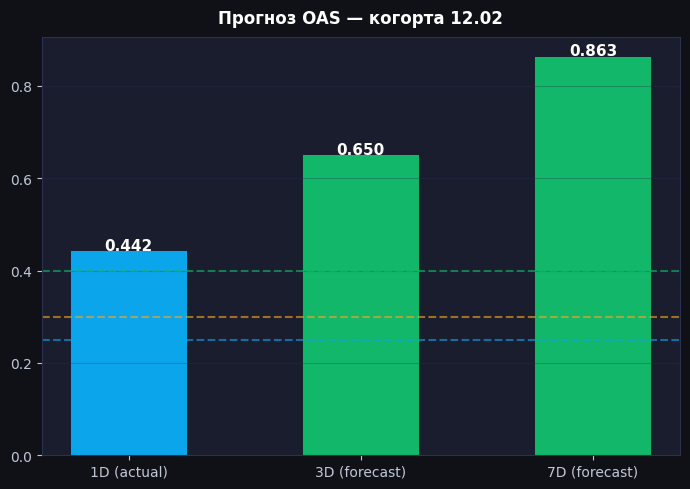

In [42]:
def forecast_oas(df, target_date, lookback=14):
    """Прогноз OAS 3D и 7D на основе медианных коэффициентов роста исторических когорт."""
    target     = pd.Timestamp(target_date)
    ratios_3d  = []
    ratios_7d  = []

    for offset in range(2, lookback + 2):
        d  = target - timedelta(days=offset)
        m1 = get_metrics(df, d, '1D')
        m3 = get_metrics(df, d, '3D')
        m7 = get_metrics(df, d, '7D')
        if not m1 or m1['oas_1d'] == 0:
            continue
        if m3 and m3['oas_3d'] > 0:
            ratios_3d.append(m3['oas_3d'] / m1['oas_1d'])
        if m7 and m7['oas_7d'] > 0:
            ratios_7d.append(m7['oas_7d'] / m1['oas_1d'])

    median_3d = np.median(ratios_3d) if ratios_3d else 1.0
    median_7d = np.median(ratios_7d) if ratios_7d else 1.0

    m_now = get_metrics(df, target_date, '1D')
    if m_now is None:
        print(f'Нет данных для когорты {target.strftime("%d.%m")}')
        return None

    oas_now     = m_now['oas_1d']
    forecast_3d = round(oas_now * median_3d, 3)
    forecast_7d = round(oas_now * median_7d, 3)
    f3 = oas_flag(forecast_3d, '3D')
    f7 = oas_flag(forecast_7d, '7D')

    print(f'\n📈 ПРОГНОЗ OAS — когорта {target.strftime("%d.%m")}')
    print(f'   На основе {len(ratios_7d)} исторических когорт')
    print(f'   Медианный коэф. роста  1D→3D: {median_3d:.3f}  |  1D→7D: {median_7d:.3f}')
    print(f'   OAS 1D (факт)    : {oas_now:.3f}')
    print(f'   OAS 3D (прогноз) : {forecast_3d:.3f}  {f3}  (порог {OAS_THRESHOLDS["3D"]})')
    print(f'   OAS 7D (прогноз) : {forecast_7d:.3f}  {f7}  (порог {OAS_THRESHOLDS["7D"]})')

    return {
        'oas_1d': oas_now, 'forecast_3d': forecast_3d, 'forecast_7d': forecast_7d,
        'median_3d': median_3d, 'median_7d': median_7d, 'n_cohorts': len(ratios_7d),
    }


forecast = forecast_oas(df, date_1d, lookback=FORECAST_LOOKBACK)

if forecast:
    fig, ax = plt.subplots(figsize=(7, 5))
    periods = ['1D (actual)', '3D (forecast)', '7D (forecast)']
    values  = [forecast['oas_1d'], forecast['forecast_3d'], forecast['forecast_7d']]
    thrs    = [OAS_THRESHOLDS['1D'], OAS_THRESHOLDS['3D'], OAS_THRESHOLDS['7D']]
    bar_colors = [
        '#0BA5EC',
        '#12B76A' if forecast['forecast_3d'] >= OAS_THRESHOLDS['3D'] else '#F04438',
        '#12B76A' if forecast['forecast_7d'] >= OAS_THRESHOLDS['7D'] else '#F04438',
    ]

    bars = ax.bar(periods, values, color=bar_colors, edgecolor='none', width=0.5)
    for thr, tc in zip(thrs, ['#0BA5EC', '#F5A623', '#12B76A']):
        ax.axhline(thr, color=tc, linestyle='--', alpha=0.6, linewidth=1.5)
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.003, f'{v:.3f}',
                ha='center', fontsize=11, fontweight='bold', color='white')

    ax.set_title(f'Прогноз OAS — когорта {date_1d.strftime("%d.%m")}' , fontweight='bold', color='white')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


## 10. Экспорт в Excel

Сохраняет `Daily_Report.xlsx` с пятью листами:
- **KPI Summary** — сводка по трём когортам с цветовой индикацией OAS
- **14D Trend** — история 1D-метрик по дням с подсветкой
- **Partners** — OAS, CPA, Profit по каждому партнёру
- **GEO & Buyers** — разбивка по странам и байерам
- **Top Bundles** — топ-20 связок по спенду


In [43]:
C_BLUE   = "1E3A5F"
C_BLUEL  = "2E5D9A"
C_WHITE  = "FFFFFF"
C_GRAY_H = "4A4A4A"
C_GRAY_R = "F5F5F5"
C_GREEN  = "0D6B2F"
C_RED    = "A93226"
C_BLACK  = "000000"

def hc(ws, r, c, v, bg=C_BLUE, fg=C_WHITE, bold=True, sz=10, align="center"):
    cell = ws.cell(row=r, column=c, value=v)
    cell.font      = Font(name="Arial", bold=bold, color=fg, size=sz)
    cell.fill      = PatternFill("solid", start_color=bg)
    cell.alignment = Alignment(horizontal=align, vertical="center", wrap_text=True)
    cell.border    = Border(left=Side(style="thin", color="CCCCCC"),
                            right=Side(style="thin", color="CCCCCC"),
                            top=Side(style="thin", color="CCCCCC"),
                            bottom=Side(style="thin", color="CCCCCC"))
    return cell

def dc(ws, r, c, v, fmt=None, bold=False, alt=False, align="center", color=C_BLACK):
    cell = ws.cell(row=r, column=c, value=v)
    cell.font      = Font(name="Arial", bold=bold, color=color, size=10)
    cell.fill      = PatternFill("solid", start_color=C_GRAY_R if alt else C_WHITE)
    cell.alignment = Alignment(horizontal=align, vertical="center")
    cell.border    = Border(left=Side(style="thin", color="E0E0E0"),
                            right=Side(style="thin", color="E0E0E0"),
                            top=Side(style="thin", color="E0E0E0"),
                            bottom=Side(style="thin", color="E0E0E0"))
    if fmt:
        cell.number_format = fmt
    return cell

def cw(ws, col, width):
    ws.column_dimensions[get_column_letter(col)].width = width

wb = Workbook()
wb.remove(wb.active)
print('Собираем Excel-отчёт...')


Собираем Excel-отчёт...


In [44]:
# Лист 1 — Сводка KPI
ws1 = wb.create_sheet("Сводка KPI")
ws1.sheet_view.showGridLines = False

ws1.merge_cells("A1:I1")
c = ws1["A1"]
c.value = f"Daily iGaming Report  |  {pd.Timestamp(BASE_DATE).strftime('%d.%m.%Y')}"
c.font  = Font(name="Arial", bold=True, color=C_WHITE, size=16)
c.fill  = PatternFill("solid", start_color=C_BLUE)
c.alignment = Alignment(horizontal="center", vertical="center")
ws1.row_dimensions[1].height = 40

ws1.merge_cells("A2:I2")
ws1["A2"].value = (f"Когорта 1D: {date_1d.strftime('%d.%m')}  |  "
                   f"Когорта 3D: {date_3d.strftime('%d.%m')}  |  "
                   f"Когорта 7D: {date_7d.strftime('%d.%m')}")
ws1["A2"].font      = Font(name="Arial", italic=True, color="666666", size=9)
ws1["A2"].alignment = Alignment(horizontal="center")
ws1.row_dimensions[2].height = 16
ws1.row_dimensions[3].height = 8

kpi_headers = ["Метрика", "1D факт", "3D факт", "7D факт",
               "Порог 1D", "Порог 3D", "Порог 7D"]
for j, h in enumerate(kpi_headers, 1):
    hc(ws1, 4, j, h, bg=C_BLUEL)
ws1.row_dimensions[4].height = 22

kpi_rows = [
    ("Spend (€)",      m1d, m3d, m7d, '—', '—', '—',                             "€#,##0"),
    ("FTD",            m1d, m3d, m7d, '—', '—', '—',                             "#,##0"),
    ("CPA (€)",        m1d, m3d, m7d, '—', '—', '—',                             "€#,##0.0"),
    ("Dep Summ (€)",   m1d, m3d, m7d, '—', '—', '—',                             "€#,##0"),
    ("CNGR (€)",       m1d, m3d, m7d, '—', '—', '—',                             "€#,##0"),
    ("Profit (€)",     m1d, m3d, m7d, '—', '—', '—',                             "€#,##0"),
    ("OAS",            m1d, m3d, m7d,
     OAS_THRESHOLDS['1D'], OAS_THRESHOLDS['3D'], OAS_THRESHOLDS['7D'],            "0.000"),
    ("Retention (%)",  m1d, m3d, m7d, '—', '—', '—',                             "0.0%"),
    ("Avg Check (€)",  m1d, m3d, m7d, '—', '—', '—',                             "€#,##0.0"),
    ("Avg P50 (€)",    m1d, m3d, m7d, '—', '—', '—',                             "€#,##0.0"),
    ("Avg P90 (€)",    m1d, m3d, m7d, '—', '—', '—',                             "€#,##0.0"),
]

key_map = {
    "Spend (€)": 'spend', "FTD": 'ftd', "CPA (€)": 'cpa',
    "Dep Summ (€)": 'dep_s', "CNGR (€)": 'cngr', "Profit (€)": 'profit',
    "OAS": 'oas', "Retention (%)": 'ret', "Avg Check (€)": 'avg_ch',
    "Avg P50 (€)": 'p50', "Avg P90 (€)": 'p90',
}

for i, (name, m_1, m_3, m_7, thr1, thr3, thr7, fmt) in enumerate(kpi_rows):
    row = 5 + i
    ws1.row_dimensions[row].height = 22
    alt = i % 2 == 1
    dc(ws1, row, 1, name, align="left", alt=alt, bold=True)
    key = key_map.get(name)
    for col_idx, (m, thr) in enumerate([(m_1, thr1), (m_3, thr3), (m_7, thr7)], 2):
        val = m[key] if (m and key) else 0
        if name == "Retention (%)":
            val = val / 100
        cell = dc(ws1, row, col_idx, val, fmt=fmt, alt=alt)
        if name == "OAS" and isinstance(thr, float):
            if val < thr:
                cell.fill = PatternFill("solid", start_color="FFCDD2")
                cell.font = Font(name="Arial", color=C_RED, bold=True, size=10)
            else:
                cell.fill = PatternFill("solid", start_color="C8E6C9")
                cell.font = Font(name="Arial", color=C_GREEN, bold=True, size=10)
    for col_idx, thr in [(5, thr1), (6, thr3), (7, thr7)]:
        dc(ws1, row, col_idx, thr, alt=alt)

if forecast:
    row = 5 + len(kpi_rows) + 1
    ws1.merge_cells(start_row=row, start_column=1, end_row=row, end_column=7)
    c = ws1.cell(row=row, column=1,
                 value=f"Прогноз OAS (когорта {date_1d.strftime('%d.%m')}):  "
                       f"3D → {forecast['forecast_3d']:.3f}  |  7D → {forecast['forecast_7d']:.3f}  "
                       f"(based on {forecast['n_cohorts']} cohorts)")
    c.font = Font(name="Arial", bold=True, color=C_WHITE, size=10)
    c.fill = PatternFill("solid", start_color=C_BLUE)
    c.alignment = Alignment(horizontal="left", vertical="center", indent=1)
    ws1.row_dimensions[row].height = 22

for i, w in enumerate([22, 12, 12, 12, 14, 14, 14], 1):
    cw(ws1, i, w)

print('  ✓ Лист 1: Сводка KPI')


  ✓ Лист 1: Сводка KPI


In [45]:
# Лист 2 — Тренд 14 дней
ws2 = wb.create_sheet("Тренд 14D")
ws2.sheet_view.showGridLines = False

ws2.merge_cells("A1:I1")
c = ws2["A1"]
c.value = "Тренд 1D-метрик за 14 дней"
c.font  = Font(name="Arial", bold=True, color=C_WHITE, size=13)
c.fill  = PatternFill("solid", start_color=C_BLUE)
c.alignment = Alignment(horizontal="center", vertical="center")
ws2.row_dimensions[1].height = 36

hdrs2 = ["Дата","Spend (€)","FTD","CPA (€)","Dep Summ (€)","OAS 1D","Retention (%)","Avg Check (€)","Profit (€)"]
for j, h in enumerate(hdrs2, 1):
    hc(ws2, 2, j, h, bg=C_BLUEL)
ws2.row_dimensions[2].height = 22

brd = Border(left=Side(style="thin", color="CCCCCC"), right=Side(style="thin", color="CCCCCC"),
             top=Side(style="thin", color="CCCCCC"),  bottom=Side(style="thin", color="CCCCCC"))

fmts2 = ["€#,##0","#,##0","€#,##0.0","€#,##0","0.000","0.0%","€#,##0.0","€#,##0"]

for i, (_, row_data) in enumerate(hist_df.iterrows()):
    row = 3 + i
    ws2.row_dimensions[row].height = 20
    alt = i % 2 == 1
    c0 = ws2.cell(row=row, column=1, value=row_data['label'])
    c0.font = Font(name="Arial", bold=True, color=C_WHITE, size=10)
    c0.fill = PatternFill("solid", start_color=C_BLUE)
    c0.alignment = Alignment(horizontal="center", vertical="center")
    c0.border = brd

    vals = [row_data['spend'], row_data['ftd'], row_data['cpa'], row_data['dep_s'],
            row_data['oas'], row_data['ret'] / 100, row_data['avg_ch'], row_data['profit']]

    for j, (v, fmt) in enumerate(zip(vals, fmts2), 2):
        cell = dc(ws2, row, j, v, fmt=fmt, alt=alt)
        if j == 6:
            if v < OAS_THRESHOLDS['1D']:
                cell.fill = PatternFill("solid", start_color="FFCDD2")
                cell.font = Font(name="Arial", color=C_RED, size=10)
            else:
                cell.fill = PatternFill("solid", start_color="C8E6C9")
                cell.font = Font(name="Arial", color=C_GREEN, size=10)

for i, w in enumerate([10,12,8,12,14,10,13,14,12], 1):
    cw(ws2, i, w)

print('  ✓ Лист 2: Тренд 14D')


  ✓ Лист 2: Тренд 14D


In [46]:
# Лист 3 — Партнёры
ws3 = wb.create_sheet("Партнёры")
ws3.sheet_view.showGridLines = False

ws3.merge_cells("A1:J1")
c = ws3["A1"]
c.value = f"Partner Breakdown  |  Cohort {date_1d.strftime('%d.%m')}  |  1D"
c.font  = Font(name="Arial", bold=True, color=C_WHITE, size=13)
c.fill  = PatternFill("solid", start_color=C_BLUE)
c.alignment = Alignment(horizontal="center", vertical="center")
ws3.row_dimensions[1].height = 36

hdrs3 = ["Партнёр","Spend (€)","FTD","CPA (€)","Dep Summ (€)","OAS","Retention (%)","Avg Check (€)","Profit (€)","Статус"]
for j, h in enumerate(hdrs3, 1):
    hc(ws3, 2, j, h, bg=C_BLUEL)
ws3.row_dimensions[2].height = 22

fmts3 = ["€#,##0","#,##0","€#,##0.0","€#,##0","0.000","0.0%","€#,##0.0","€#,##0"]
for i, (_, row_data) in enumerate(partners_1d.iterrows()):
    row = 3 + i
    ws3.row_dimensions[row].height = 22
    alt = i % 2 == 1
    dc(ws3, row, 1, str(row_data['Partner']), align="left", alt=alt, bold=True)
    vals = [row_data['spend'], row_data['ftd'], row_data['cpa'], row_data['dep_s'],
            row_data['oas'], row_data['ret'] / 100, row_data['avg_ch'], row_data['profit']]
    for j, (v, fmt) in enumerate(zip(vals, fmts3), 2):
        dc(ws3, row, j, v, fmt=fmt, alt=alt)
    ok   = row_data['oas'] >= OAS_THRESHOLDS['1D']
    cell = dc(ws3, row, 10, "ОК" if ok else "Ниже порога", alt=alt, bold=True,
              color=C_GREEN if ok else C_RED)

for i, w in enumerate([18,12,8,12,14,10,13,14,12,16], 1):
    cw(ws3, i, w)

print('  ✓ Лист 3: Партнёры')


  ✓ Лист 3: Партнёры


In [47]:
# Лист 4 — GEO и Байеры
ws4 = wb.create_sheet("GEO и Байеры")
ws4.sheet_view.showGridLines = False

ws4.merge_cells("A1:I1")
c = ws4["A1"]
c.value = f"GEO & Buyers  |  Cohort {date_1d.strftime('%d.%m')}  |  1D"
c.font  = Font(name="Arial", bold=True, color=C_WHITE, size=13)
c.fill  = PatternFill("solid", start_color=C_BLUE)
c.alignment = Alignment(horizontal="center", vertical="center")
ws4.row_dimensions[1].height = 36

def write_section(ws, start_row, title, data, dim_col, col_headers):
    ws.merge_cells(start_row=start_row, start_column=1, end_row=start_row, end_column=len(col_headers))
    tc = ws.cell(row=start_row, column=1, value=title)
    tc.font = Font(name="Arial", bold=True, color=C_WHITE, size=11)
    tc.fill = PatternFill("solid", start_color=C_BLUEL)
    tc.alignment = Alignment(horizontal="left", vertical="center", indent=1)
    ws.row_dimensions[start_row].height = 24

    for j, h in enumerate(col_headers, 1):
        hc(ws, start_row + 1, j, h, bg=C_GRAY_H)
    ws.row_dimensions[start_row + 1].height = 20

    fmts = ["€#,##0","#,##0","€#,##0.0","€#,##0","0.000","0.0%","€#,##0"]
    for i, (_, row_data) in enumerate(data.iterrows()):
        row = start_row + 2 + i
        ws.row_dimensions[row].height = 20
        alt = i % 2 == 1
        dc(ws, row, 1, str(row_data[dim_col]), alt=alt, bold=True)
        vals = [row_data['spend'], row_data['ftd'], row_data['cpa'], row_data['dep_s'],
                row_data['oas'], row_data['ret'] / 100, row_data['profit']]
        for j, (v, fmt) in enumerate(zip(vals, fmts), 2):
            dc(ws, row, j, v, fmt=fmt, alt=alt)
        ok = row_data['oas'] >= OAS_THRESHOLDS['1D']
        dc(ws, row, len(col_headers), "🟢" if ok else "🔴", alt=alt)
    return start_row + 2 + len(data)

col_hdrs = ["GEO","Spend (€)","FTD","CPA (€)","Dep Summ (€)","OAS","Retention (%)","Profit (€)",""]
next_row = write_section(ws4, 2,  "GEO",    geo_1d,    'GEO',   col_hdrs)
col_hdrs[0] = "Байер"
write_section(ws4, next_row + 2, "Байеры", buyers_1d, 'Buyer', col_hdrs)

for i, w in enumerate([14,12,8,12,14,10,13,12,6], 1):
    cw(ws4, i, w)

print('  ✓ Лист 4: GEO и Байеры')


  ✓ Лист 4: GEO и Байеры


In [48]:
# Лист 5 — Топ связки
ws5 = wb.create_sheet("Топ связки")
ws5.sheet_view.showGridLines = False

ws5.merge_cells("A1:J1")
c = ws5["A1"]
c.value = f"Top Bundles by Spend  |  Cohort {date_1d.strftime('%d.%m')}  |  1D"
c.font  = Font(name="Arial", bold=True, color=C_WHITE, size=13)
c.fill  = PatternFill("solid", start_color=C_BLUE)
c.alignment = Alignment(horizontal="center", vertical="center")
ws5.row_dimensions[1].height = 36

hdrs5 = ["#","Связка","Spend (€)","FTD","CPA (€)","Dep Summ (€)","OAS","Ret (%)","Profit (€)","Статус"]
for j, h in enumerate(hdrs5, 1):
    hc(ws5, 2, j, h, bg=C_BLUEL)
ws5.row_dimensions[2].height = 22

fmts5 = ["€#,##0","#,##0","€#,##0.0","€#,##0","0.000","0.0%","€#,##0"]
for i, (_, row_data) in enumerate(bundles_1d.head(20).iterrows()):
    row = 3 + i
    ws5.row_dimensions[row].height = 20
    alt  = i % 2 == 1
    dc(ws5, row, 1, i + 1, alt=alt)
    dc(ws5, row, 2, str(row_data['Bundle']), align="left", alt=alt)
    vals = [row_data['spend'], row_data['ftd'], row_data['cpa'], row_data['dep_s'],
            row_data['oas'], row_data['ret'] / 100, row_data['profit']]
    for j, (v, fmt) in enumerate(zip(vals, fmts5), 3):
        dc(ws5, row, j, v, fmt=fmt, alt=alt)
    ok   = row_data['oas'] >= OAS_THRESHOLDS['1D']
    cell = dc(ws5, row, 10, "ОК" if ok else "Below", alt=alt, bold=True,
              color=C_GREEN if ok else C_RED)

for i, w in enumerate([5, 30, 12, 8, 12, 14, 10, 10, 12, 12], 1):
    cw(ws5, i, w)

wb.save(EXCEL_OUT)
print('  ✓ Лист 5: Топ связки')
print(f"\n✅ {EXCEL_OUT}")


  ✓ Лист 5: Топ связки

✅ Daily_Report.xlsx
